In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
# ==========================================
# 1. TẢI TĂNG DẦN TUYẾN TÍNH (Linearly Increasing Workload)
# ==========================================
# Theo bài báo: Giả lập 215 khoảng thời gian, mỗi khoảng 1 phút [cite: 290]
t_increasing = np.arange(1, 216) 

# Các tham số giả định (Em có thể tùy chỉnh để khớp với sức chịu tải của vi dịch vụ của em):
w_i_t0 = 5500  # w_i(t_o): Số lượng request khởi điểm [cite: 291, 300]
delta_w_i = 1900 # \Delta w_i: Mức tăng cố định sau mỗi phút [cite: 291, 300]

# Áp dụng Công thức (3) trong bài báo: w_i(t) = w_i(t_o) + (t-1) * \Delta w_i [cite: 300]
w_linear = w_i_t0 + (t_increasing - 1) * delta_w_i

In [8]:
# ==========================================
# 2. TẠO NHIỄU "RỒ GẦN" (ROUGH NOISE)
# ==========================================
# Kết hợp Sóng Sin và Nhiễu ngẫu nhiên để tạo đường răng cưa tự nhiên
np.random.seed(42) # Đặt seed để kết quả ổn định mỗi lần chạy

# a)  Sóng sin lớn:
periodic_max = 1500 * np.sin(2 * np.pi * t_increasing / 15)

# b) Sóng sin nhỏ (Periodic Noise): Tạo chu kỳ lên/xuống nhỏ
periodic_min = 1200 * np.sin(2 * np.pi * t_increasing / 5)

# c) Nhiễu ngẫu nhiên (Random Noise): Tạo các răng cưa nhỏ, sắc nhọn
# (Độ lệch chuẩn 800 tạo ra biến động vừa phải xung quanh đường xu hướng)
random_noise = np.random.normal(0, 800, size=len(t_increasing))


# c) Tổng hợp nhiễu rồ ghề
total_workload = w_linear + periodic_max + periodic_min + random_noise

# Đảm bảo giá trị request là số nguyên (integer) và không bị âm
w_increasing = np.maximum(np.round(total_workload), 0).astype(int)

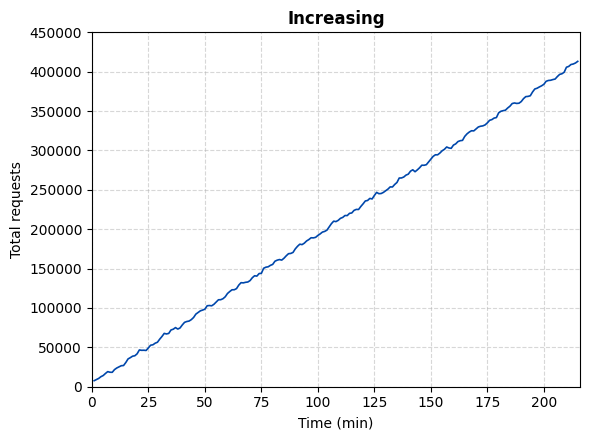

In [9]:

# ==========================================
# 3. VẼ BIỂU ĐỒ TRỰC QUAN (Giống Hình 5c và 5d) 
# ==========================================
plt.figure(figsize=(6, 4.5))
plt.plot(t_increasing, w_increasing, color='#0047AB', linewidth=1.2)
plt.title("Increasing", fontsize=12, fontweight='bold')
plt.xlabel("Time (min)",  fontsize=10)
plt.ylabel("Total requests", fontsize=10)

plt.xlim(0, 216)


plt.ylim(0, 450000)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Lưu ảnh
plt.savefig('../../workload_generation/data/increasing_workload.png', dpi=300)
plt.show()

In [10]:
# ==========================================
# 4. LƯU DỮ LIỆU ĐỂ DÙNG CHO MÔ HÌNH HỌC MÁY
# ==========================================
df_increasing = pd.DataFrame({'time': t_increasing, 'requests': w_increasing})

df_increasing.to_csv('../../workload_generation/data/increasing_workload.csv', index=False)

print("Đã tạo và lưu thành công")

Đã tạo và lưu thành công
